In [1]:
import os
from PIL import Image
import torch
from torchvision import models, transforms
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2  # OpenCV
import numpy as np
import pandas as pd
import random

In [5]:
print(os.getcwd())

c:\CV\uts


c:\Users\Deniel\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Deniel\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting features: 100%|██████████| 4262/4262 [01:33<00:00, 45.57it/s]
c:\Users\Deniel\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this 

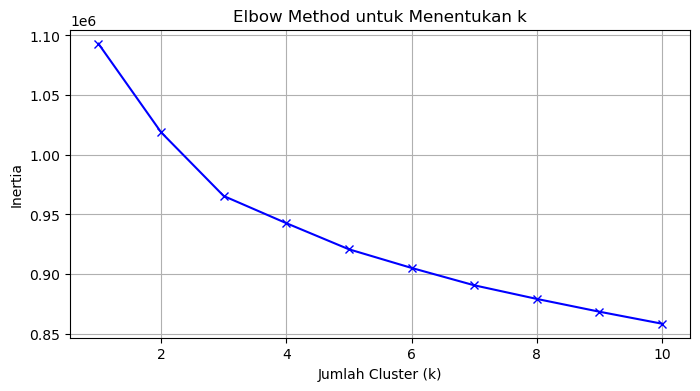

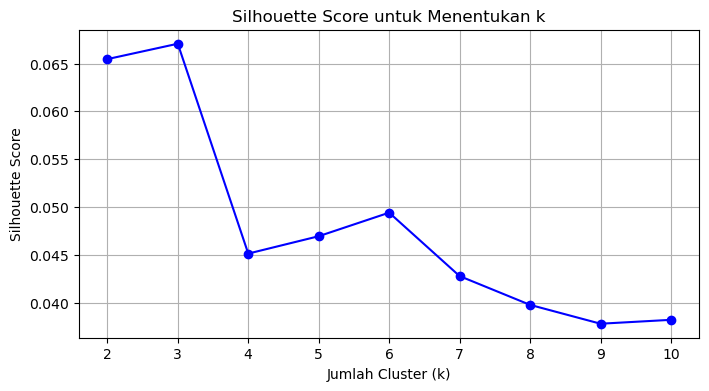

In [2]:
image_folder = "sports_ball_images_full"

# Ambil semua file gambar
image_paths = [os.path.join(image_folder, fname) 
               for fname in os.listdir(image_folder) 
               if fname.lower().endswith((".jpg", ".jpeg", ".png"))]

# Optional: batasi jumlah gambar untuk testing
# image_paths = image_paths[:100]

# === Load pre-trained ResNet50 dan hilangkan FC layer ===
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # buang classifier
model.eval()

# === Image transform ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# === Ekstrak fitur dari gambar ===
features = []

for path in tqdm(image_paths, desc="Extracting features"):
    try:
        img = Image.open(path).convert("RGB")
        x = transform(img).unsqueeze(0)  # batch size 1
        with torch.no_grad():
            feat = model(x).squeeze().numpy()
        features.append(feat)
    except Exception as e:
        print(f"Error loading {path}: {e}")

features = np.array(features)

# === Elbow Method ===
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan k')
plt.grid(True)
plt.show()

# === Silhouette Score ===
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features)
    score = silhouette_score(features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan k')
plt.grid(True)
plt.show()

In [3]:
# Ubah ke path folder gambar kamu
folder_path = 'sports_ball_images_full'
image_data = []

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (64, 64))  # Resize ke ukuran yang konsisten
        img = img.flatten()  # Ubah jadi 1D array
        image_data.append(img)

image_data = np.array(image_data)  # Sekarang ini bisa dipakai untuk KMeans

In [4]:
best_score = -1
best_state = None
k = 3  # atau jumlah cluster terbaik dari Elbow/Silhouette sebelumnya

for state in range(0, 100):  # coba 100 kemungkinan random state
    kmeans = KMeans(n_clusters=k, random_state=state)
    labels = kmeans.fit_predict(image_data)

    score = silhouette_score(image_data, labels)
    
    if score > best_score:
        best_score = score
        best_state = state

print(f"Random state terbaik: {best_state} dengan silhouette score: {best_score:.4f}")

Random state terbaik: 81 dengan silhouette score: 0.1006


In [5]:
kmeans = KMeans(n_clusters= 3, random_state=81)
labels = kmeans.fit_predict(image_data)  


In [6]:
df = pd.DataFrame({
    'image_path': image_paths,
    'cluster': labels
})
df.to_csv("hasil_clustering_sportsball.csv", index=False)

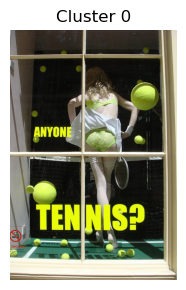

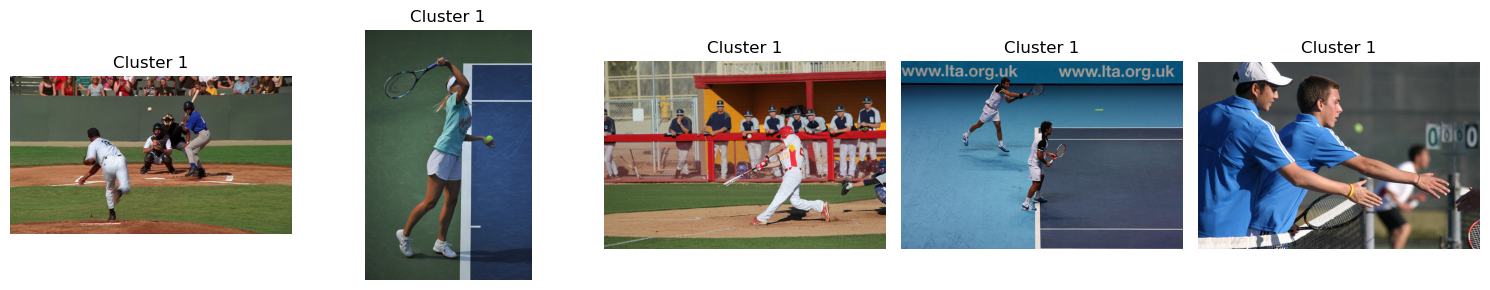

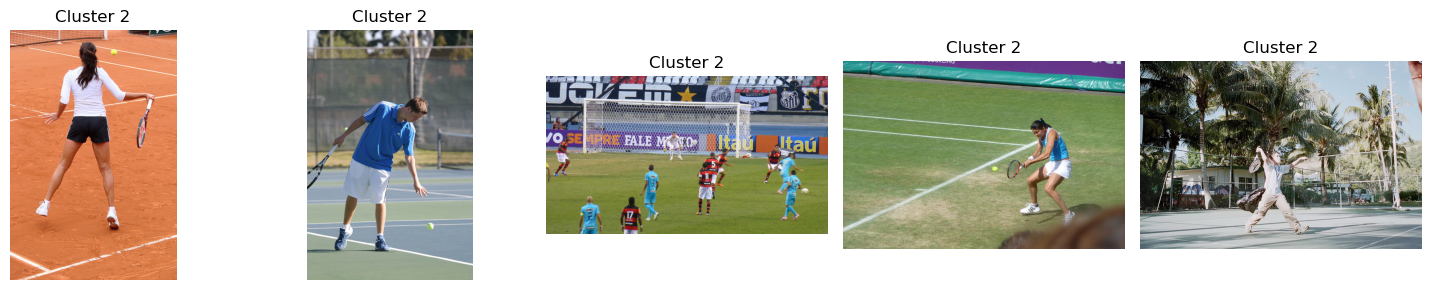

In [7]:
def show_cluster_examples(cluster_id, n=5):
    sample_paths = [p for p, c in zip(image_paths, labels) if c == cluster_id]
    sample_paths = random.sample(sample_paths, min(n, len(sample_paths)))

    plt.figure(figsize=(15, 3))
    for i, path in enumerate(sample_paths):
        img = Image.open(path).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Cluster {cluster_id}")
    plt.tight_layout()
    plt.show()

# Tampilkan contoh dari tiap cluster
for cid in range(3):
    show_cluster_examples(cid)

In [8]:
import shutil
from pathlib import Path

output_base = Path("cluster_output")
output_base.mkdir(exist_ok=True)

for path, label in zip(image_paths, labels):
    cluster_dir = output_base / f"cluster_{label}"
    cluster_dir.mkdir(exist_ok=True)
    shutil.copy(path, cluster_dir / Path(path).name)


In [9]:
from collections import defaultdict

cluster_samples = defaultdict(list)

# Kumpulkan path berdasarkan label cluster
for path, label in zip(image_paths, labels):
    cluster_samples[label].append(path)

# Acak isi cluster
for label in cluster_samples:
    random.shuffle(cluster_samples[label])

# Gabungkan dan ambil maksimal 50 total gambar
combined = []
for label in cluster_samples:
    combined.extend([(p, label) for p in cluster_samples[label]])

# Acak gabungan dan ambil maksimal 50
random.shuffle(combined)
sampled = combined[:50]

# Pisahkan kembali path dan label jika dibutuhkan
sampled_paths = [p for p, _ in sampled]
sampled_labels = [l for _, l in sampled]

print(f"Total sample terpilih: {len(sampled_paths)}")

Total sample terpilih: 50


In [10]:
import shutil
from pathlib import Path

output_dir = Path("final_sampled_50")
output_dir.mkdir(exist_ok=True)

for i, (path, label) in enumerate(sampled):
    fname = f"{label}_{i}_{Path(path).name}"
    shutil.copy(path, output_dir / fname)


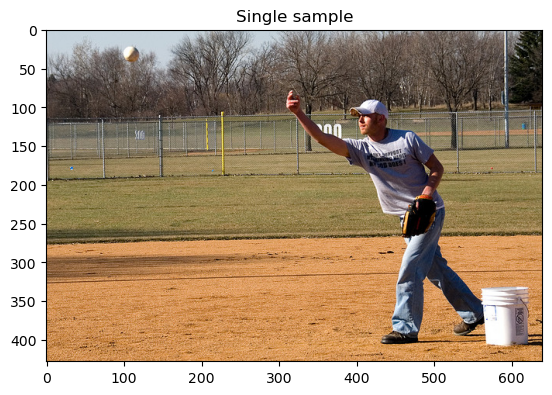

In [11]:
folder = "single_sample"
img = os.listdir(folder)
img = [f for f in img if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Load dan tampilkan gambar pertama
img_path = os.path.join(folder, img[0])
image = Image.open(img_path)

plt.imshow(image)
plt.title("Single sample")
plt.show()

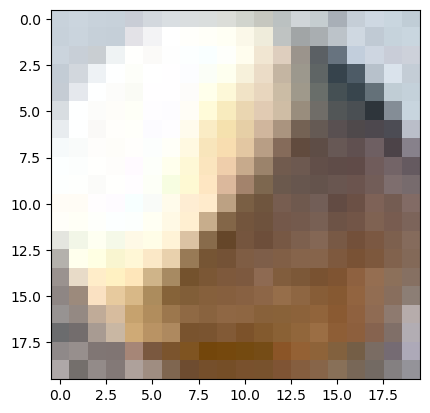

In [12]:
image1 = cv2.imread(os.path.join(folder, img[0]))
x, y, w, h = 100, 22, 20, 20 # Adjust these values as needed
template = image1[y:y+h, x:x+w]
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Display the cropped template
plt.imshow(template_rgb)

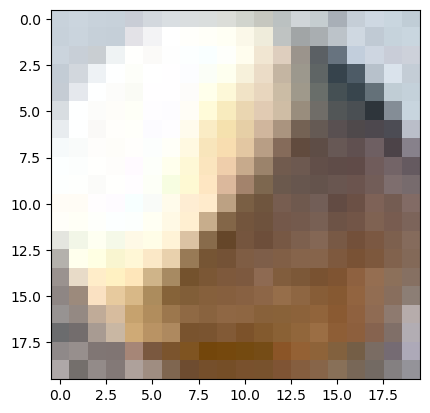

In [13]:
tmp_img = template_rgb
plt.imshow(tmp_img)

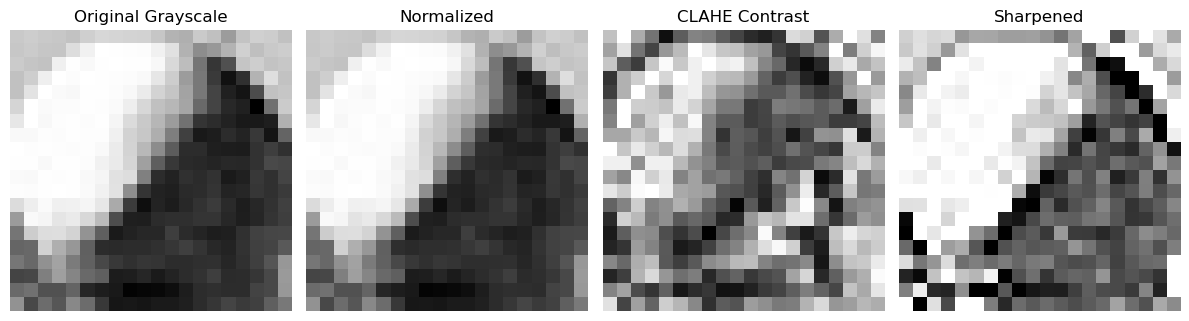

In [14]:
# === Load gambar ===
image_gray = cv2.cvtColor(tmp_img, cv2.COLOR_BGR2GRAY)  # ubah ke grayscale

# === 1. Normalisasi (Min-Max Scaling ke 0–255) ===
normalized = cv2.normalize(image_gray, None, 0, 255, cv2.NORM_MINMAX)

# === 2. Peningkatan Kontras dengan CLAHE ===
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(image_gray)

# === 3. Penajaman Citra (Sharpening) ===
# Kernel penajaman
kernel = np.array([[0, -1,  0],
                   [-1, 5, -1],
                   [0, -1,  0]])
sharpened = cv2.filter2D(image_gray, -1, kernel)

# === Tampilkan hasilnya ===
images = [image_gray, normalized, contrast, sharpened]
titles = ["Original Grayscale", "Normalized", "CLAHE Contrast", "Sharpened"]

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [15]:
tmp_img
print(tmp_img.shape)

(20, 20, 3)


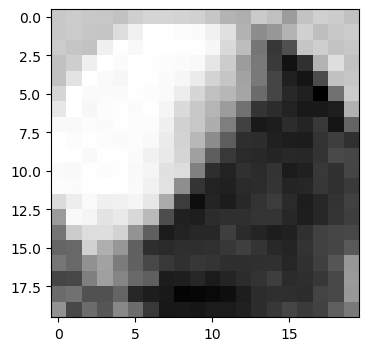

In [16]:
image_gray = cv2.cvtColor(tmp_img, cv2.COLOR_BGR2GRAY)  # ubah ke grayscale

# === 1. Normalisasi (Min-Max Scaling ke 0–255) ===
normalized = cv2.normalize(image_gray, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(12, 4))
plt.tight_layout()
plt.imshow(normalized, cmap='gray')
plt.show()


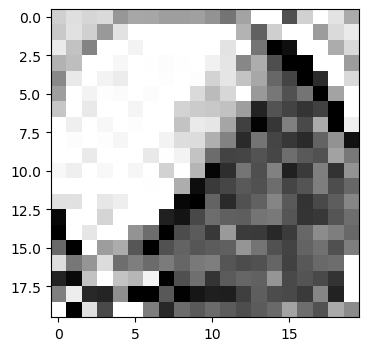

In [17]:
kernel = np.array([[0, -1,  0],
                   [-1, 5, -1],
                   [0, -1,  0]])
sharpened = cv2.filter2D(image_gray, -1, kernel)

plt.figure(figsize=(12, 4))
plt.tight_layout()
plt.imshow(sharpened, cmap='gray')
plt.show()

In [18]:
print(image_gray)

[[212 215 212 211 207 217 223 222 221 219 210 196 192 213 205 177 208 218
  215 206]
 [211 214 210 209 228 244 255 254 253 252 244 231 194 165 174 196 218 204
  212 215]
 [214 209 207 243 254 250 254 255 254 254 249 225 203 146  97 117 209 216
  208 211]
 [206 216 242 255 252 255 254 253 252 250 235 215 177 149 100  68  93 195
  229 207]
 [206 233 255 251 249 254 254 252 249 239 220 209 183 149 108  80  70 114
  206 210]
 [222 255 251 252 252 254 253 251 241 223 205 198 184 138 108  86  80  54
  143 214]
 [236 255 249 253 254 252 254 247 226 212 197 177 144  96  89  81  74  74
   78 193]
 [250 250 253 252 254 253 253 243 219 211 191 153 105  74  77  89  82  98
   70 133]
 [255 253 254 253 252 253 250 239 220 199 164 127  90  89  79  77  76  94
  103  93]
 [254 254 250 254 254 252 244 238 222 180 128  98  87  86  83  86  85  94
  112 109]
 [251 250 254 253 254 250 247 231 228 155  90  81  92  88  94  75  80  98
   92 108]
 [253 252 254 255 254 251 244 232 166  96  81  79  87  89  95  82

In [19]:
print(normalized)

[[200 204 200 199 194 207 214 213 212 209 198 180 175 202 192 156 195 208
  204 193]
 [199 203 198 197 221 241 255 254 252 251 241 225 178 141 152 180 208 190
  200 204]
 [203 197 194 240 254 249 254 255 254 254 247 217 189 117  55  80 197 206
  195 199]
 [193 206 239 255 251 255 254 252 251 249 230 204 156 121  58  18  49 179
  222 194]
 [193 227 255 250 247 254 254 251 247 235 211 197 164 121  69  33  20  76
  193 198]
 [213 255 250 251 251 254 252 250 237 214 192 183 165 107  69  41  33   0
  113 203]
 [231 255 247 252 254 251 254 245 218 200 181 156 114  53  44  34  25  25
   30 176]
 [249 249 252 251 254 252 252 240 209 199 174 126  65  25  29  44  36  56
   20 100]
 [255 252 254 252 251 252 249 235 211 184 140  93  46  44  32  29  28  51
   62  49]
 [254 254 249 254 254 251 241 233 213 160  94  56  42  41  37  41  39  51
   74  70]
 [250 249 254 252 254 249 245 225 221 128  46  34  48  43  51  27  33  56
   48  69]
 [252 251 254 255 254 250 241 226 142  53  34  32  42  44  52  36

### 2. Teknik CV

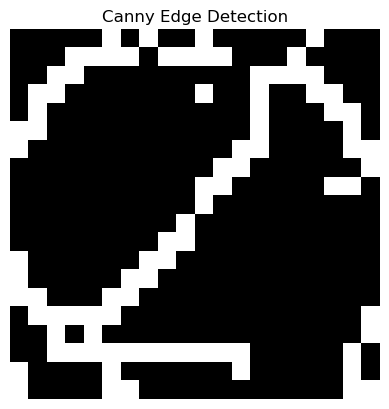

In [20]:
# EDGE DETECTION using CANNY

edges = cv2.Canny(image_gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

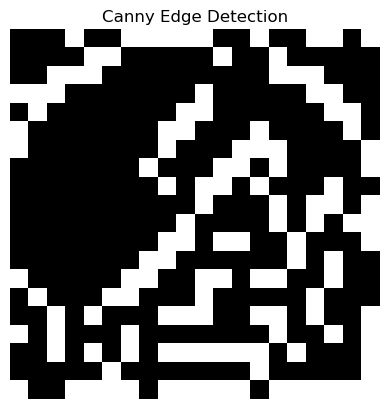

In [54]:
edges = cv2.Canny(sharpened, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

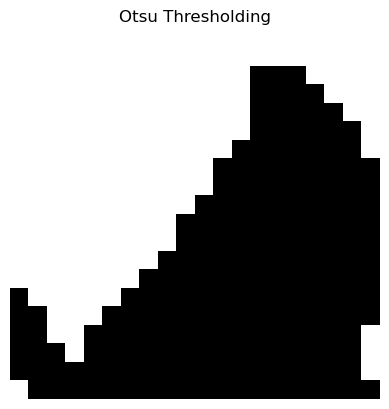

In [21]:
# TRESHOLDING using OTSU

_, thresh = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis('off')
plt.show()

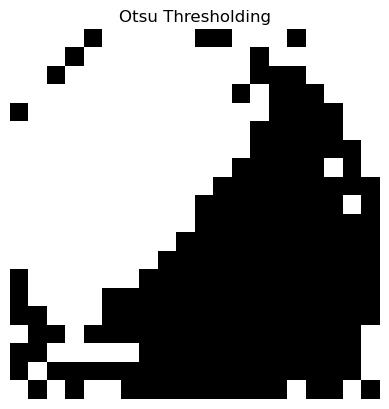

In [55]:
_, thresh = cv2.threshold(sharpened, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis('off')
plt.show()

In [43]:
normalized1 = normalized.astype(np.uint8)

In [56]:
sp = sharpened.astype(np.uint8)

In [45]:
print("Markers dtype:", markers.dtype)

Markers dtype: int32


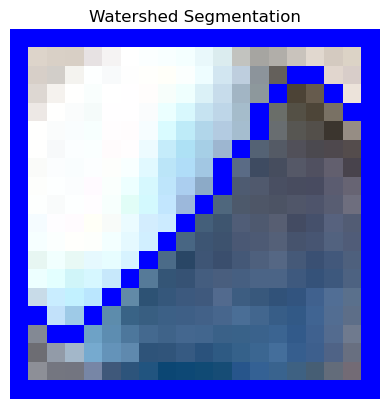

In [22]:
# SEGMENTAION using WATERSHED

# 1. Binarisasi
_, binary = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Noise removal
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 3. Background & foreground
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# 4. Marker labeling
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# 5. Watershed
original = tmp_img
markers = cv2.watershed(original, markers)
original[markers == -1] = [255, 0, 0 ]  # Tepi objek ditandai biru

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis('off')
plt.show()

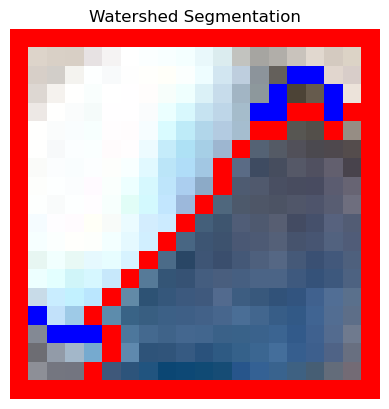

In [59]:
# 1. Binarisasi
_, binary = cv2.threshold(sp, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Noise removal
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 3. Background & foreground
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# 4. Marker labeling
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# 5. Watershed
original = tmp_img
markers = cv2.watershed(original, markers)
original[markers == -1] = [0 , 0, 255]  # Tepi objek ditandai merah

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis('off')
plt.show()

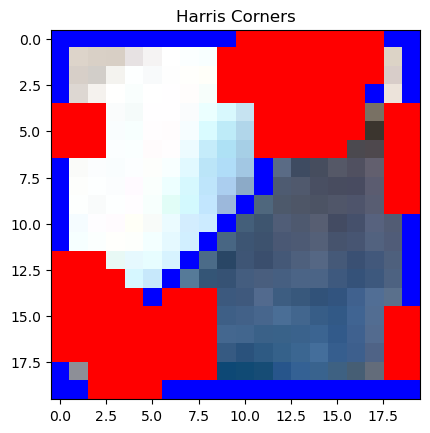

In [26]:
# Fitur detection dengan harris corner detection
gray = image_gray

# Convert to float32
gray = np.float32(gray)

# Harris corner detection
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Dilate to mark the corners
dst = cv2.dilate(dst, None)

# Threshold for an optimal value
tmp_img[dst > 0.01 * dst.max()] = [0, 0, 255]

# Show image
plt.imshow(cv2.cvtColor(tmp_img, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners')
plt.show()

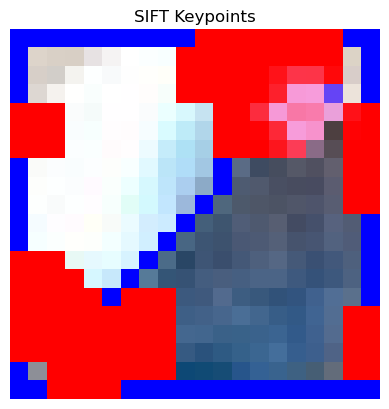

In [27]:
# using SIFT

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(image_gray, None)
img_sift = cv2.drawKeypoints(tmp_img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis('off')
plt.show()

### 3. <b><i>Convolution<i><b>

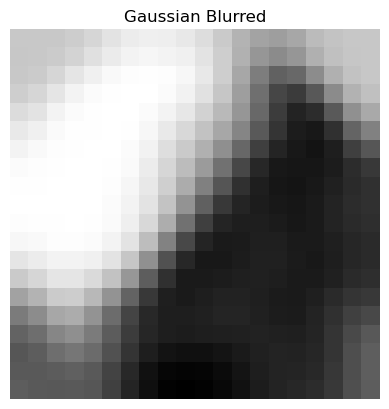

In [20]:
# Gaussian blur

blurred = cv2.GaussianBlur(image_gray, (5, 5), 1)  # (kernel_size, sigmaX)

# Tampilkan dengan matplotlib
plt.imshow(blurred, cmap='gray')  # cmap='gray' untuk grayscale
plt.title('Gaussian Blurred')
plt.axis('off')  # Hilangkan axis
plt.show()

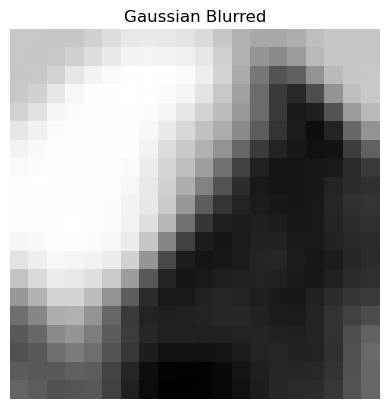

In [22]:
blurred = cv2.GaussianBlur(image_gray, (3, 3), 0)  # (kernel_size, sigmaX)

# Tampilkan dengan matplotlib
plt.imshow(blurred, cmap='gray')  # cmap='gray' untuk grayscale
plt.title('Gaussian Blurred')
plt.axis('off')  # Hilangkan axis
plt.show()

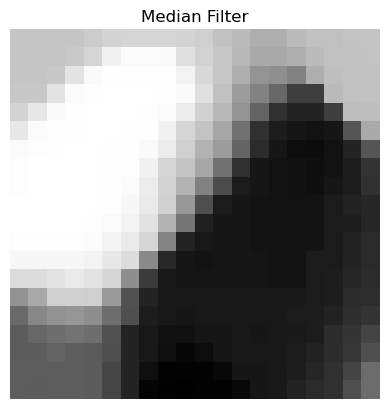

In [21]:
# Median filter

median = cv2.medianBlur(image_gray, 5)

plt.imshow(median, cmap='gray')  # cmap='gray' untuk grayscale
plt.title('Median Filter')
plt.axis('off')  # Hilangkan axis
plt.show()

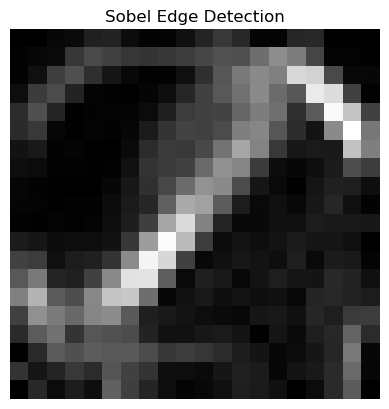

In [23]:
# sobel

sobelx = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)  # X direction
sobely = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)  # Y direction

# Compute the magnitude of the gradient
sobel_combined = cv2.magnitude(sobelx, sobely)

# Show result
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.show()

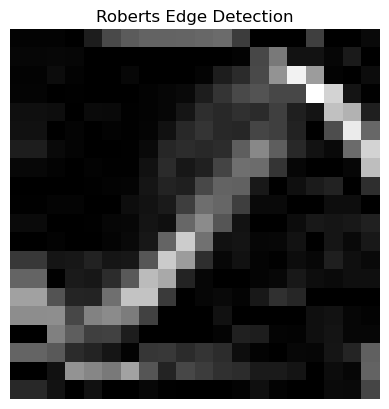

In [24]:
# robert

kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

# Convolve dengan filter
gx = cv2.filter2D(image_gray, -1, kernel_x)
gy = cv2.filter2D(image_gray, -1, kernel_y)

# Gabungkan hasil gradien
edge = cv2.convertScaleAbs(np.abs(gx) + np.abs(gy))

# Tampilkan hasil
plt.imshow(edge, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')
plt.show()

### 4. Morfologi

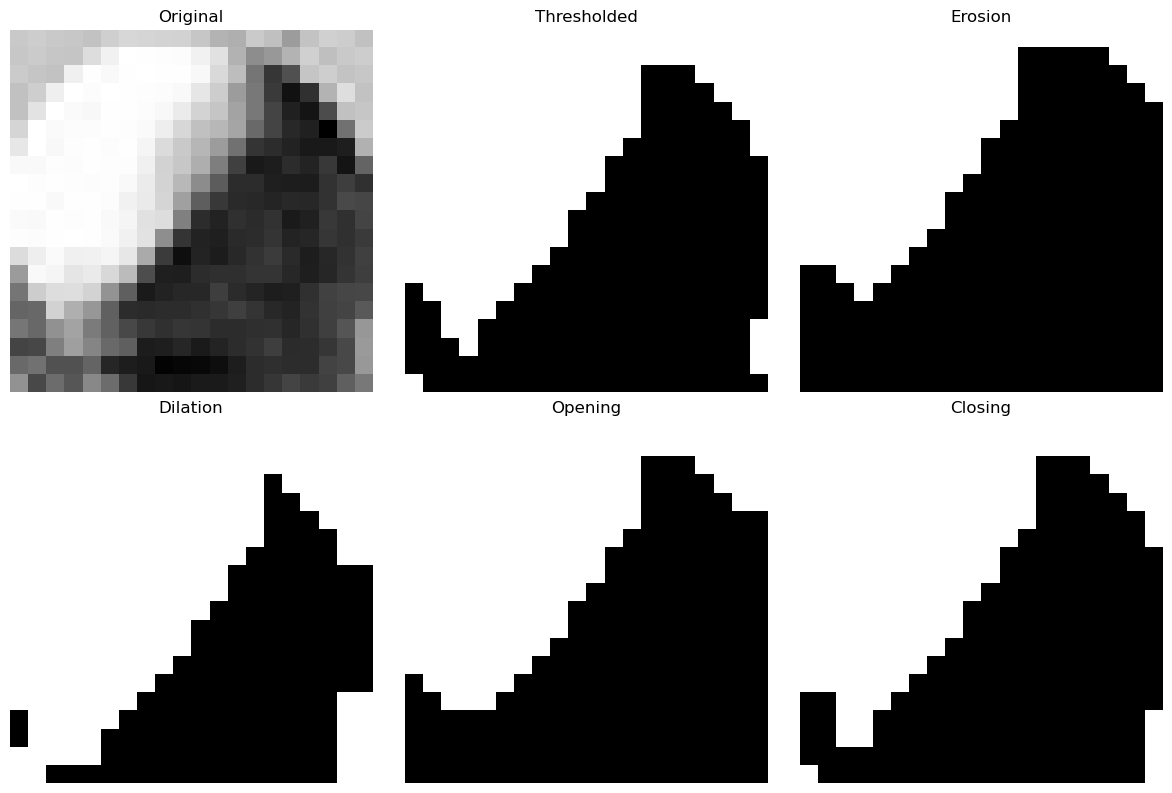

In [26]:
# opening, closing, erosi, dilasi

gray = image_gray

# 2. Thresholding (bisa pakai Otsu)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Definisikan kernel (struktur elemen)
kernel = np.ones((3, 3), np.uint8)

# 4. Lakukan morfologi
eroded = cv2.erode(thresh, kernel, iterations=1)
dilated = cv2.dilate(thresh, kernel, iterations=1)
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# 5. Tampilkan hasil
titles = ['Original', 'Thresholded', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [gray, thresh, eroded, dilated, opened, closed]

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Jumlah lubang: 1


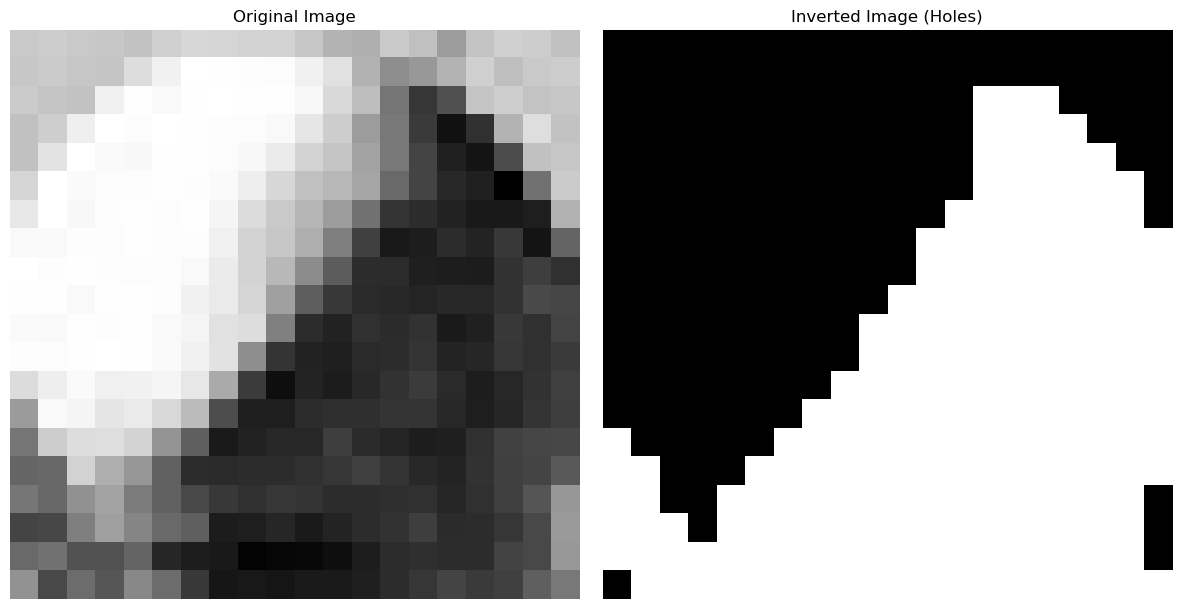

In [27]:
# menghitung lubang

_, binary = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert image to have objects as white and background as black
inv = cv2.bitwise_not(binary)

# Find connected components (to detect holes)
num_labels, labels = cv2.connectedComponents(inv)

# Subtract 1 to exclude background (label 0)
num_holes = num_labels - 1
print(f"Jumlah lubang: {num_holes}")

# Display original and processed images
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Inverted binary image with holes marked
plt.subplot(1, 2, 2)
plt.imshow(inv, cmap='gray')
plt.title('Inverted Image (Holes)')
plt.axis('off')

plt.tight_layout()
plt.show()

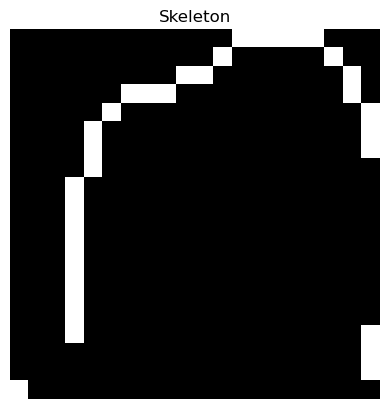

In [29]:
# Skeleton

from skimage.morphology import skeletonize
from skimage.util import invert

binary_bool = binary // 255

# Skeletonize
skeleton = skeletonize(binary_bool)

plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton')
plt.axis('off')
plt.show()

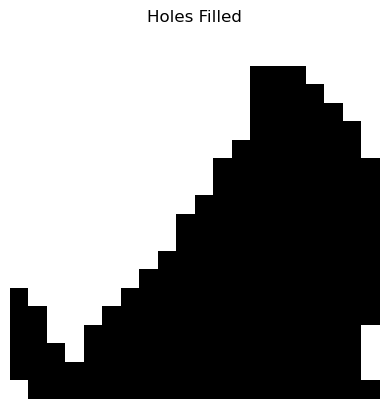

In [30]:
# Fill hole

from scipy.ndimage import binary_fill_holes

filled = binary_fill_holes(binary_bool).astype(np.uint8) * 255

plt.imshow(filled, cmap='gray')
plt.title('Holes Filled')
plt.axis('off')
plt.show()

### 5. Deteksi fitur pencocokan